# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
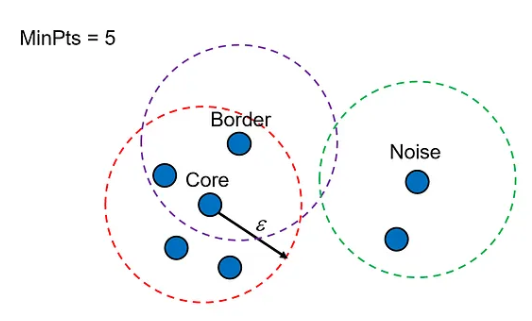

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

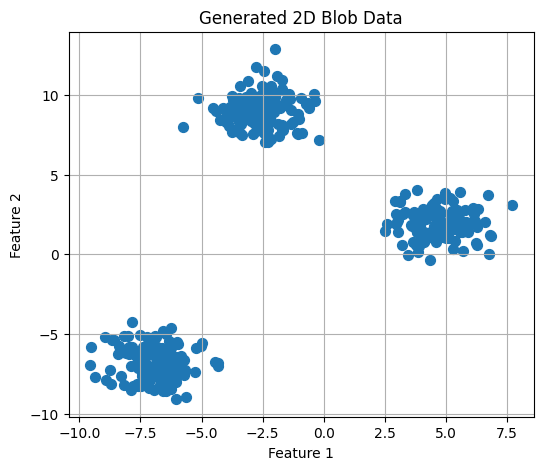

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [36]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

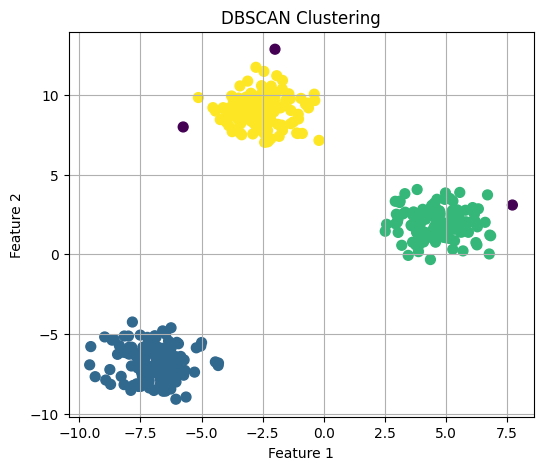

In [37]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [38]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [39]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

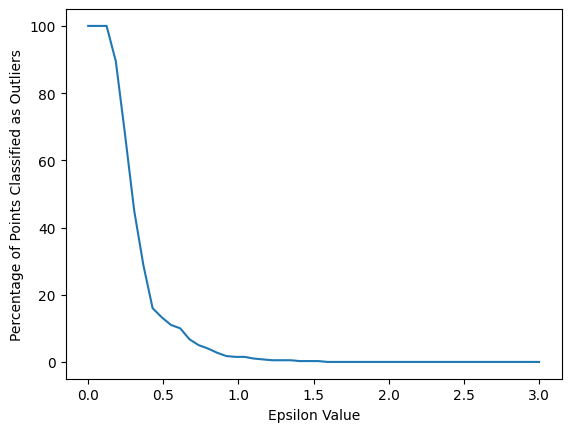

In [40]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

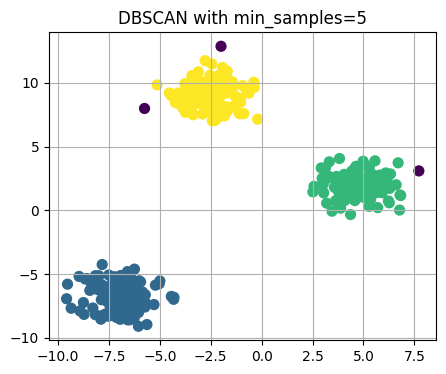

min_samples=5 → Silhouette Score: 0.848


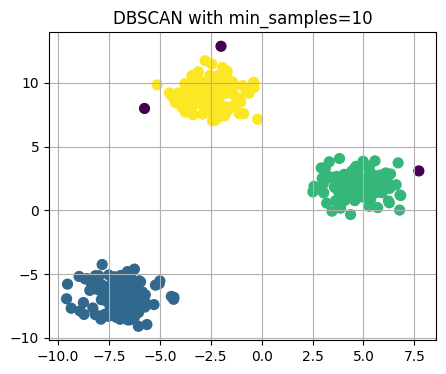

min_samples=10 → Silhouette Score: 0.848


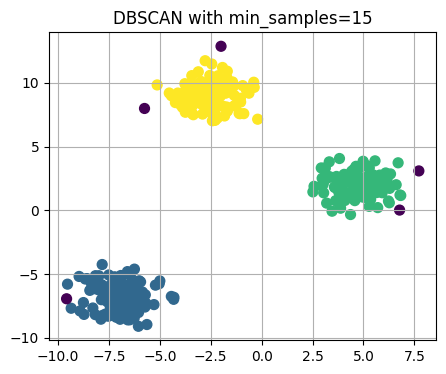

min_samples=15 → Silhouette Score: 0.849


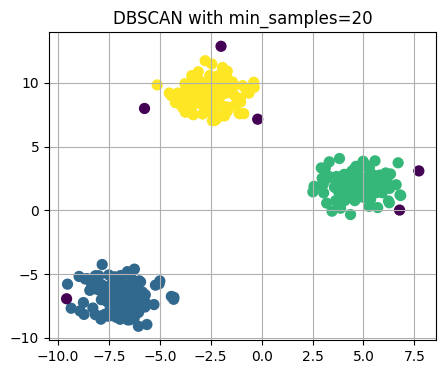

min_samples=20 → Silhouette Score: 0.850


In [41]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("CC GENERAL.csv")

print("Shape:", df.shape)
df.head()

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [43]:
# Identify Numeric vs Categorical Features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

Categorical Features:
['CUST_ID']


In [44]:
# Numeric Feature Distributions
stats = df[numeric_features].describe().T
stats["skewness"] = df[numeric_features].skew()
print(stats)

                                   count         mean          std        min  \
BALANCE                           8950.0  1564.474828  2081.531879   0.000000   
BALANCE_FREQUENCY                 8950.0     0.877271     0.236904   0.000000   
PURCHASES                         8950.0  1003.204834  2136.634782   0.000000   
ONEOFF_PURCHASES                  8950.0   592.437371  1659.887917   0.000000   
INSTALLMENTS_PURCHASES            8950.0   411.067645   904.338115   0.000000   
CASH_ADVANCE                      8950.0   978.871112  2097.163877   0.000000   
PURCHASES_FREQUENCY               8950.0     0.490351     0.401371   0.000000   
ONEOFF_PURCHASES_FREQUENCY        8950.0     0.202458     0.298336   0.000000   
PURCHASES_INSTALLMENTS_FREQUENCY  8950.0     0.364437     0.397448   0.000000   
CASH_ADVANCE_FREQUENCY            8950.0     0.135144     0.200121   0.000000   
CASH_ADVANCE_TRX                  8950.0     3.248827     6.824647   0.000000   
PURCHASES_TRX               

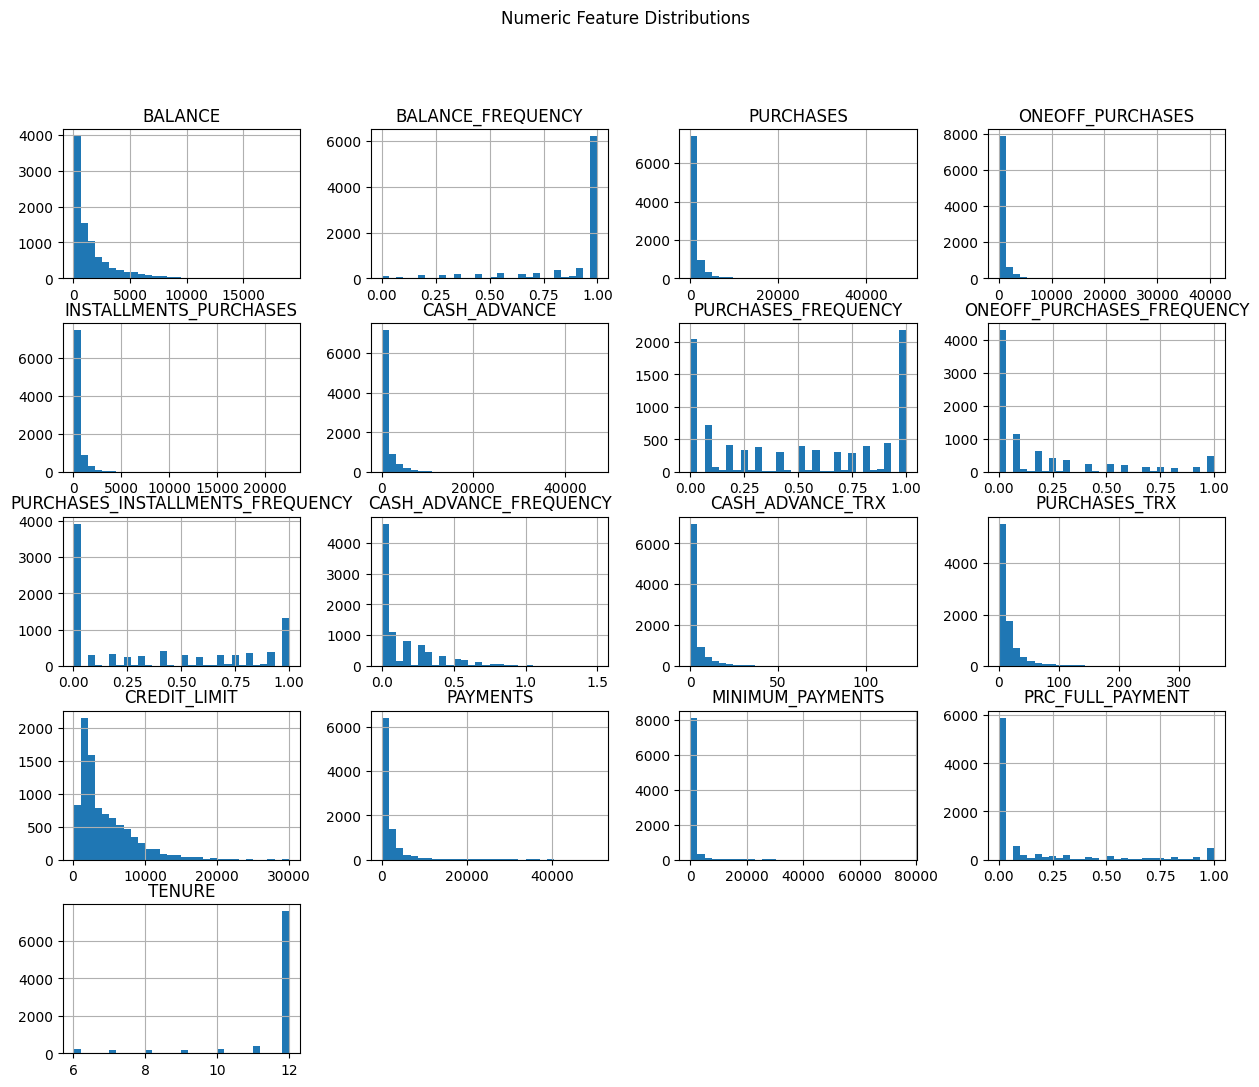

In [45]:
df[numeric_features].hist(figsize=(15,12), bins=30)
plt.suptitle("Numeric Feature Distributions")
plt.show()

In [46]:
# Missing Values Analysis
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


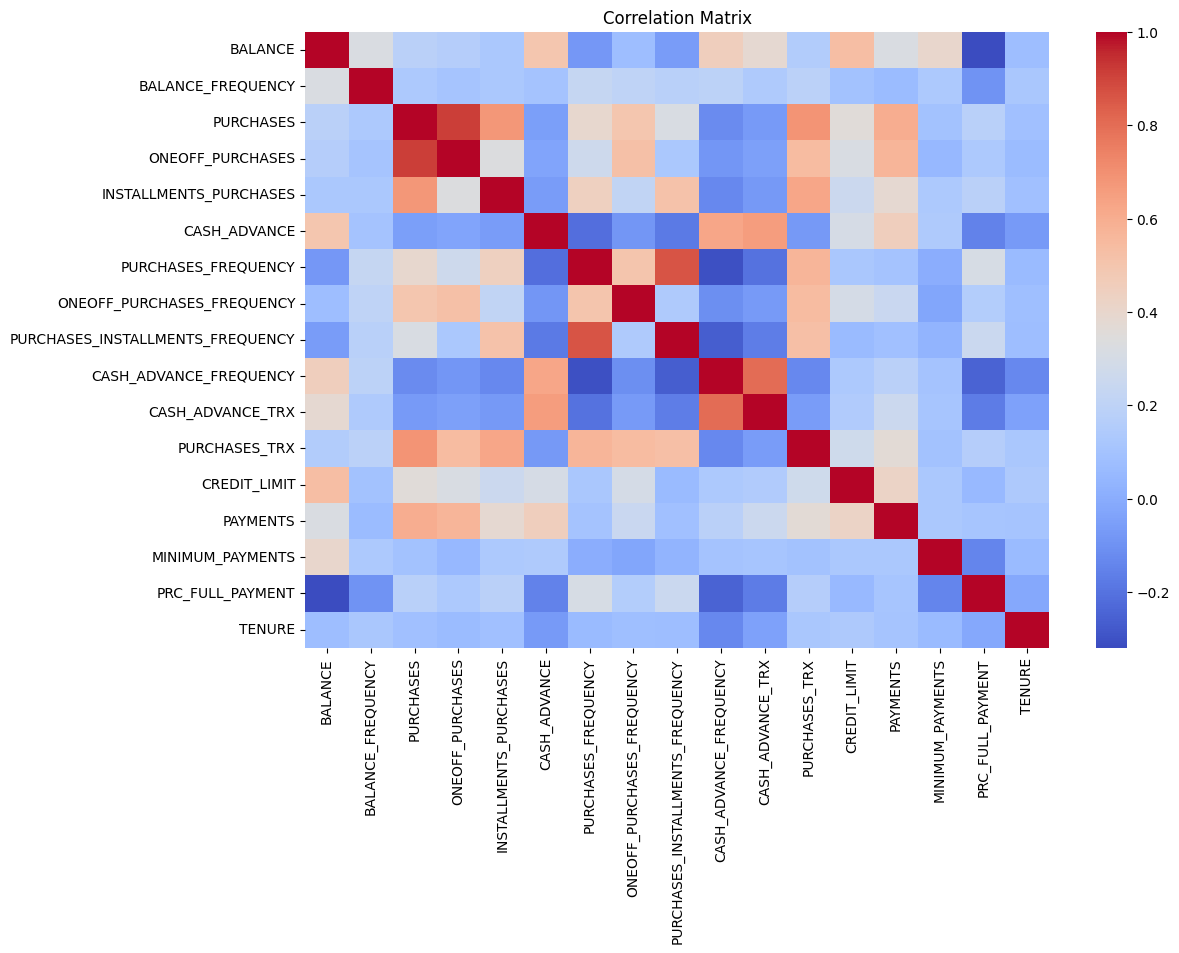

In [47]:
# Correlation Between Numeric Features
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_features].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [48]:
# Outlier Detection
print("Outlier counts per feature (IQR method):\n")

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Outlier counts per feature (IQR method):

BALANCE: 695 outliers
BALANCE_FREQUENCY: 1493 outliers
PURCHASES: 808 outliers
ONEOFF_PURCHASES: 1013 outliers
INSTALLMENTS_PURCHASES: 867 outliers
CASH_ADVANCE: 1030 outliers
PURCHASES_FREQUENCY: 0 outliers
ONEOFF_PURCHASES_FREQUENCY: 782 outliers
PURCHASES_INSTALLMENTS_FREQUENCY: 0 outliers
CASH_ADVANCE_FREQUENCY: 525 outliers
CASH_ADVANCE_TRX: 804 outliers
PURCHASES_TRX: 766 outliers
CREDIT_LIMIT: 248 outliers
PAYMENTS: 808 outliers
MINIMUM_PAYMENTS: 841 outliers
PRC_FULL_PAYMENT: 1474 outliers
TENURE: 1366 outliers


<Figure size 1500x1000 with 0 Axes>

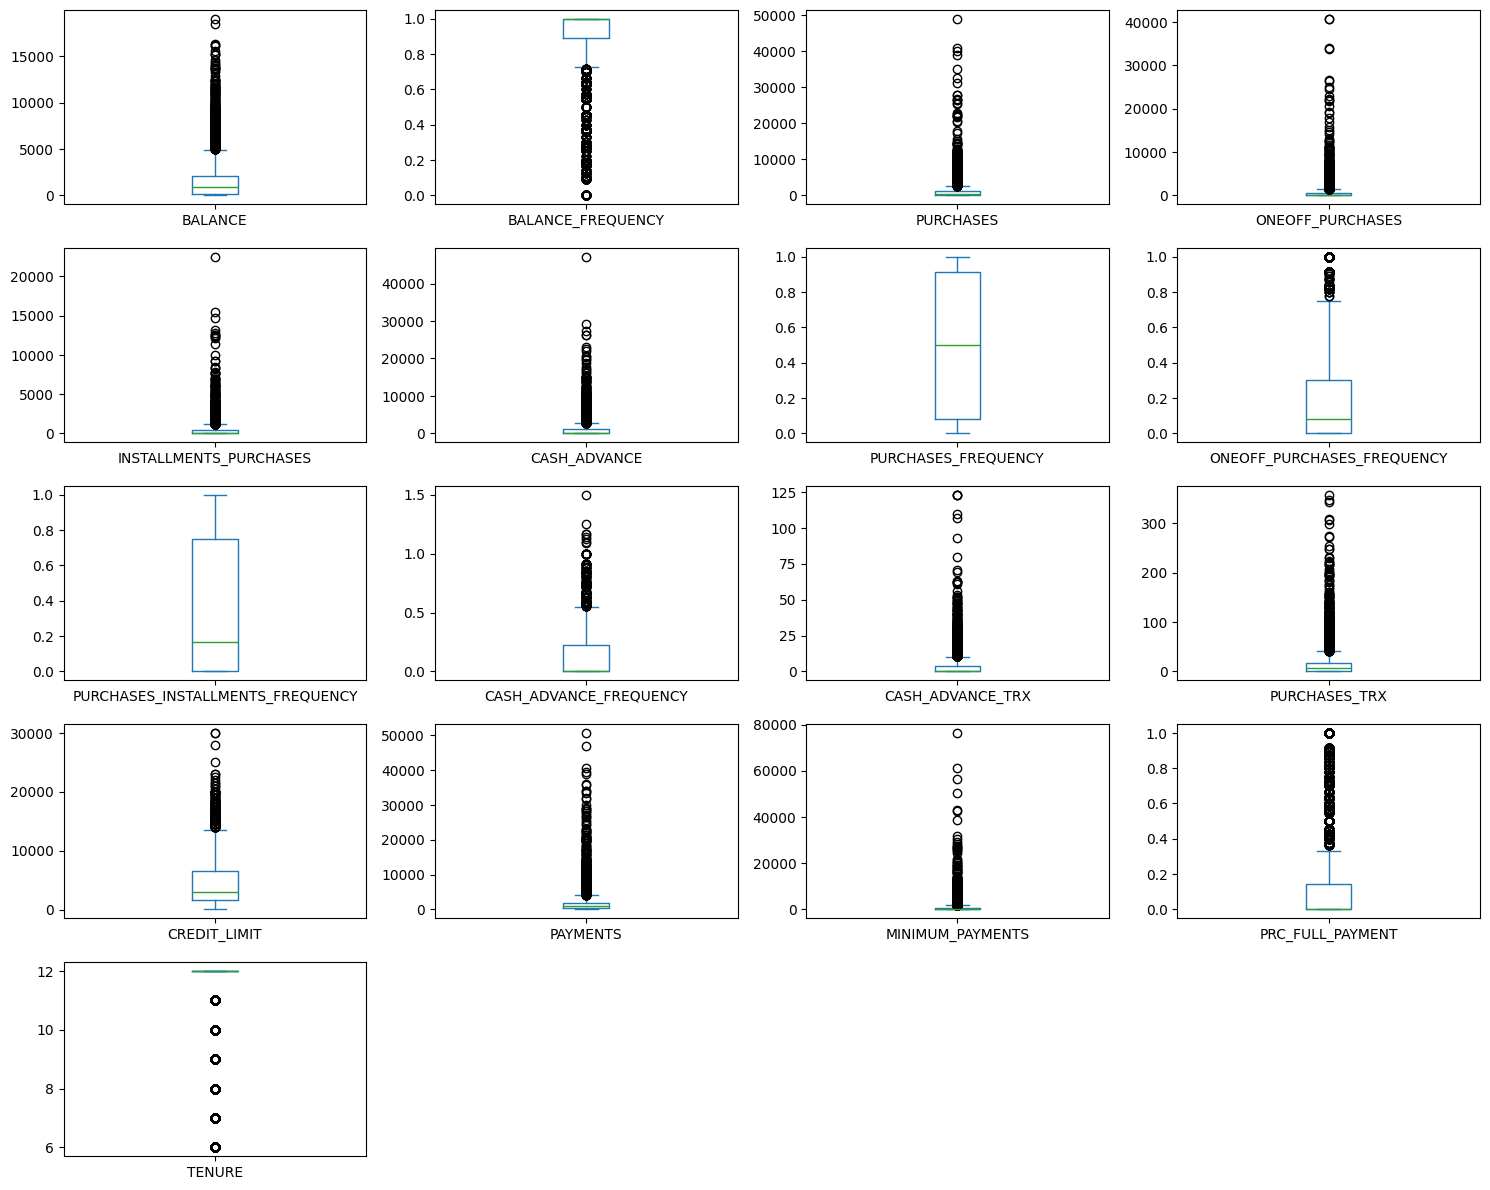

In [49]:
# Boxplots
plt.figure(figsize=(15,10))
df[numeric_features].plot(kind='box', subplots=True, layout=(5,4), figsize=(15,12))
plt.tight_layout()
plt.show()

## 2. Data Preparation

In [50]:
# Drop Irrelevant / Target Columns
# Drop identifier column
if "CUST_ID" in df.columns:
    df = df.drop(columns=["CUST_ID"])

print("Shape after dropping irrelevant columns:", df.shape)

Shape after dropping irrelevant columns: (8950, 17)


In [51]:
# Scale Numeric Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert back to DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print(df_scaled.head())

    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.731989          -0.249434  -0.424900         -0.356934   
1  0.786961           0.134325  -0.469552         -0.356934   
2  0.447135           0.518084  -0.107668          0.108889   
3  0.049099          -1.016953   0.232058          0.546189   
4 -0.358775           0.518084  -0.462063         -0.347294   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0               -0.349079     -0.466786            -0.806490   
1               -0.454576      2.605605            -1.221758   
2               -0.454576     -0.466786             1.269843   
3               -0.454576     -0.368653            -1.014125   
4               -0.454576     -0.466786            -1.014125   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                   -0.678661                         -0.707313   
1                   -0.678661                         -0.916995   
2                    2.673451      

In [52]:
###Drop highly correlated feature (>0.9)###

corr_matrix = df_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

df_scaled = df_scaled.drop(columns=to_drop)

print("Dropped:", to_drop)

Dropped: ['ONEOFF_PURCHASES']


In [59]:
from sklearn.preprocessing import StandardScaler

# Fill missing values (e.g., with mean)
df.fillna(df.mean(), inplace=True)

# Drop non-numeric or ID columns (if any)
df_prep = df.drop(['CUST_ID'], axis=1, errors='ignore')  # Only if 'CUST_ID' exists

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_prep)

print(df_scaled[:5])

[[-7.31989366e-01 -2.49434481e-01 -4.24899735e-01 -3.56934022e-01
  -3.49078819e-01 -4.66785554e-01 -8.06490346e-01 -6.78660808e-01
  -7.07313165e-01 -6.75348858e-01 -4.76069817e-01 -5.11333250e-01
  -9.60433344e-01 -5.28978791e-01 -3.10967549e-01 -5.25550971e-01
   3.60679544e-01]
 [ 7.86960853e-01  1.34324671e-01 -4.69551882e-01 -3.56934022e-01
  -4.54576230e-01  2.60560451e+00 -1.22175806e+00 -6.78660808e-01
  -9.16995191e-01  5.73962722e-01  1.10073852e-01 -5.91795877e-01
   6.88639034e-01  8.18642127e-01  8.93102090e-02  2.34226897e-01
   3.60679544e-01]
 [ 4.47135132e-01  5.18083823e-01 -1.07668230e-01  1.08888513e-01
  -4.54576230e-01 -4.66785554e-01  1.26984323e+00  2.67345108e+00
  -9.16995191e-01 -6.75348858e-01 -4.76069817e-01 -1.09020117e-01
   8.26061732e-01 -3.83804738e-01 -1.01663181e-01 -5.25550971e-01
   3.60679544e-01]
 [ 4.90991395e-02 -1.01695278e+00  2.32057847e-01  5.46189456e-01
  -4.54576230e-01 -3.68653254e-01 -1.01412545e+00 -3.99319268e-01
  -9.16995191e-01 -

In [53]:
print("Missing values:", df_scaled.isnull().sum().sum())

Missing values: 314


In [54]:
print("All numeric:",
      df_scaled.select_dtypes(exclude=['number']).shape[1] == 0)

All numeric: True


In [55]:
print("Final dataset shape:", df_scaled.shape)

Final dataset shape: (8950, 16)


## 3. Apply DBSCAN




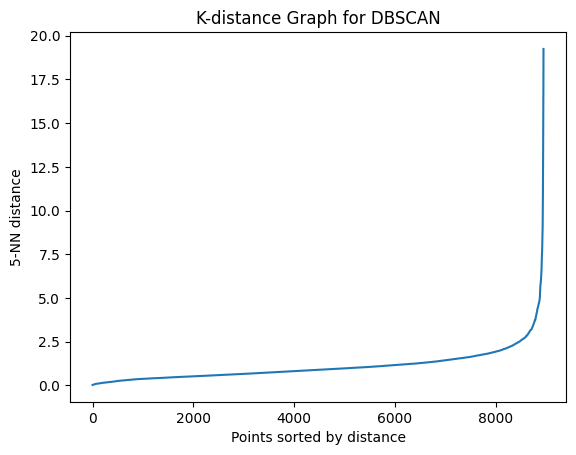

In [60]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Find optimal eps using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Sort distances to find the "knee"
distances = np.sort(distances[:,4])
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('5-NN distance')
plt.title('K-distance Graph for DBSCAN')
plt.show()

In [61]:
# Apply DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=5)
clusters = dbscan.fit_predict(df_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = clusters

# View cluster counts
print(df['Cluster'].value_counts())

Cluster
 0    8609
-1     341
Name: count, dtype: int64


In [62]:
# Show outlier customers
outliers = df[df['Cluster'] == -1]
print(outliers.describe())

# Compare with the main cluster
main_cluster = df[df['Cluster'] == 0]
print(main_cluster.describe())

            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count    341.000000         341.000000    341.000000        341.000000   
mean    4917.498682           0.935818   5977.234575       3750.919150   
std     3786.738108           0.166374   7512.523289       6246.000983   
min        4.382924           0.090909      0.000000          0.000000   
25%     1930.900813           1.000000    717.240000          0.000000   
50%     4194.033835           1.000000   3950.000000       1282.850000   
75%     6983.408463           1.000000   8710.720000       4192.800000   
max    19043.138560           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count              341.000000    341.000000           341.000000   
mean              2228.139472   4326.316955             0.715267   
std               3101.482347   6143.535020             0.370669   
min                  0.000000      0.000000             0.000

## 4. Evaluate the Clustering

In [68]:
import numpy as np
from sklearn.metrics import silhouette_score

labels = dbscan.labels_

# Count clusters and noise
unique_labels = np.unique(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print("Number of clusters:", n_clusters)
print("Noise points:", n_noise)
print("Noise percentage:", n_noise / len(labels) * 100)

# Calculate Silhouette Score only if 2 or more clusters
mask = labels != -1
if n_clusters > 1:
    score = silhouette_score(df_scaled[mask], labels[mask])
    print(f"Silhouette Score (without noise): {score:.3f}")
else:
    print("Silhouette Score cannot be calculated: less than 2 clusters after removing noise.")

Number of clusters: 1
Noise points: 341
Noise percentage: 3.8100558659217874
Silhouette Score cannot be calculated: less than 2 clusters after removing noise.


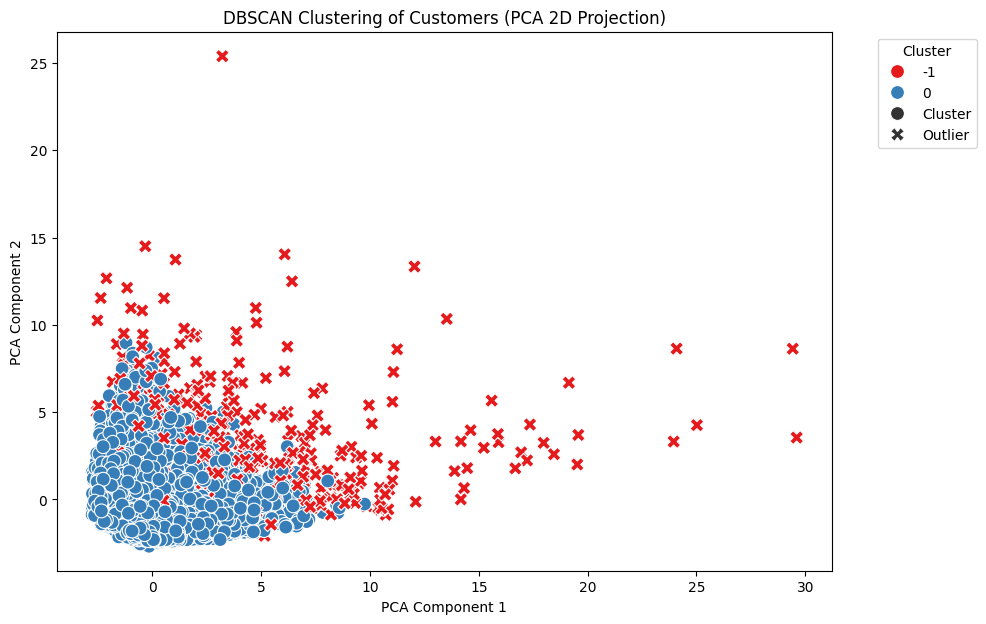

In [65]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Assume df_scaled is your standardized data and df['Cluster'] contains DBSCAN labels

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Plot
plt.figure(figsize=(10,7))
palette = sns.color_palette("Set1", n_colors=len(df['Cluster'].unique()))
sns.scatterplot(
    x=df_pca[:,0],
    y=df_pca[:,1],
    hue=df['Cluster'],
    palette=palette,
    style=df['Cluster'].apply(lambda x: 'Outlier' if x == -1 else 'Cluster'),
    s=100
)
plt.title('DBSCAN Clustering of Customers (PCA 2D Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()